## Model creation and training

### Correlation Matrix for dataset features

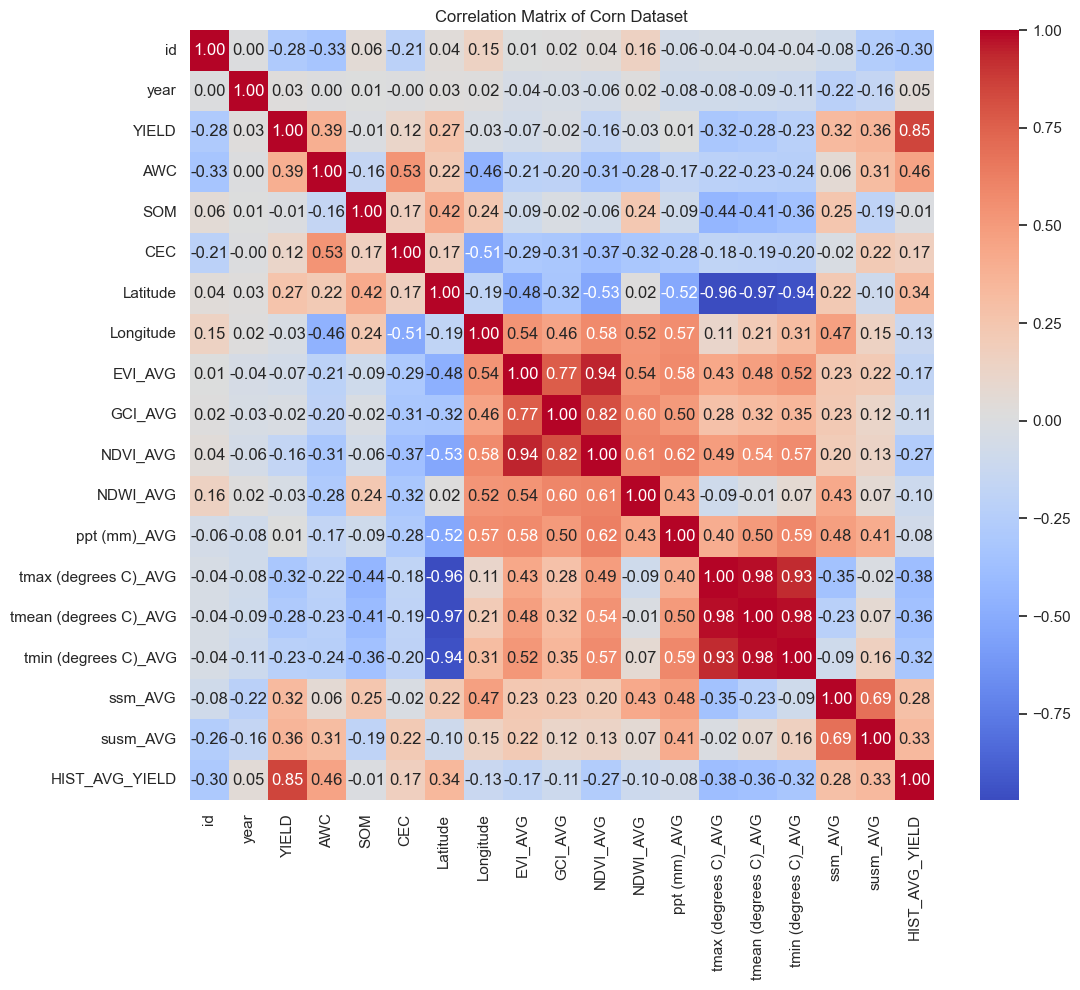

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Load the dataset
df = pd.read_csv("corn_dataset_final.csv")

# 2️⃣ Select numeric columns only for correlation
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# 3️⃣ Plot correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Corn Dataset")
plt.show()

In [17]:
# ------------------------------
# Load & Prepare Dataset (Year kept only for split/eval)
# ------------------------------
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("corn_dataset_final.csv")

# --- Config ---
TRAIN_YEARS = [2016, 2017, 2018, 2019, 2020, 2021]
TEST_YEARS  = [2020, 2021, 2022]  # test on last 2 years
TARGET_COL  = "YIELD"

# Filter train/test years
train_df_all = df[df["year"].isin(TRAIN_YEARS)].copy()
test_df      = df[df["year"].isin(TEST_YEARS)].copy()

# ------------------------------
# Encode states
# ------------------------------
states = sorted(train_df_all["state_name"].unique())
state_to_idx = {s: i for i, s in enumerate(states)}
train_df_all["state_idx"] = train_df_all["state_name"].map(state_to_idx)
test_df["state_idx"]      = test_df["state_name"].map(state_to_idx)

# ------------------------------
# Feature columns
# ------------------------------
# Drop year entirely from features
feature_cols = [
    "ppt (mm)_AVG", "tmax (degrees C)_AVG", "tmean (degrees C)_AVG", "tmin (degrees C)_AVG",  # climate
    "ssm_AVG", "susm_AVG",  # soil
    "EVI_AVG", "GCI_AVG", "NDWI_AVG", "NDVI_AVG",  # satellite
    "AWC", "SOM", "CEC", "state_idx",  # static
    "HIST_AVG_YIELD"  # new historical average yield feature
]

# Columns to scale (all except target & year)
scaler_X = StandardScaler()
train_df_all[feature_cols] = scaler_X.fit_transform(train_df_all[feature_cols])
test_df[feature_cols]      = scaler_X.transform(test_df[feature_cols])

# Scale target
scaler_y = StandardScaler()
train_df_all["YIELD_STD"] = scaler_y.fit_transform(train_df_all[[TARGET_COL]])
test_df["YIELD_STD"]      = scaler_y.transform(test_df[[TARGET_COL]])

# ------------------------------
# Dataset class (flattened for single cross-attention)
# ------------------------------
class FlattenedCornDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
        self.feature_cols = feature_cols
        self.target_col = "YIELD_STD"

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        X = torch.tensor(row[self.feature_cols].to_numpy(dtype=np.float32), dtype=torch.float32)
        y = torch.tensor(float(row[self.target_col]), dtype=torch.float32).unsqueeze(0)
        return X, y

# ------------------------------
# Create datasets & loaders
# ------------------------------
full_train_dataset = FlattenedCornDataset(train_df_all)
test_dataset       = FlattenedCornDataset(test_df)

train_idx, val_idx = train_test_split(
    range(len(full_train_dataset)),
    test_size=0.2,
    random_state=42
)

train_dataset = torch.utils.data.Subset(full_train_dataset, train_idx)
val_dataset   = torch.utils.data.Subset(full_train_dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

# ------------------------------
# Input info
# ------------------------------
sample_X, sample_y = train_dataset[0]

print(f"Flattened feature vector: {sample_X.shape[0]}")
print(f"Target shape: {sample_y.shape}")


Flattened feature vector: 15
Target shape: torch.Size([1])


In [18]:
class EarlyStopping:
    def __init__(self, patience=50, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.stop = True

In [19]:
import torch.optim as optim
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import torch
import torch.nn as nn

# ------------------------------
# Cross-Attention Block
# ------------------------------
class FeatureCrossAttentionBlock(nn.Module):
    def __init__(self, dim, num_heads, dropout=0.2):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(dim, num_heads, batch_first=True, dropout=dropout)
        self.cross_attn = nn.MultiheadAttention(dim, num_heads, batch_first=True, dropout=dropout)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.norm3 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.ReLU(),
            nn.Linear(dim * 2, dim)
        )

    def forward(self, x, context=None):
        # Self-attention: features attend to each other
        x = self.norm1(x + self.self_attn(x, x, x)[0])

        # Cross-attention: features attend to external context (optional)
        if context is not None:
            x = self.norm2(x + self.cross_attn(x, context, context)[0])

        # Feed-forward
        x = self.norm3(x + self.ffn(x))
        return x

# ------------------------------
# Tabular Transformer with Self + Cross Attention
# ------------------------------
class CornYieldTransformer(nn.Module):
    def __init__(self, n_features, emb_dim=128, num_heads=8, num_blocks=2, dropout=0.1):
        super().__init__()

        # 1) Feature-wise embedding (each scalar → emb_dim vector)
        self.feature_emb = nn.ModuleList([nn.Linear(1, emb_dim) for _ in range(n_features)])

        # 2) Positional embeddings for each feature
        self.pos_emb = nn.Parameter(torch.randn(n_features, emb_dim))

        # 3) Stacked self + cross attention blocks
        self.blocks = nn.ModuleList([
            FeatureCrossAttentionBlock(emb_dim, num_heads, dropout) for _ in range(num_blocks)
        ])

        # 4) Prediction head
        self.predictor = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim // 2),
            nn.ReLU(),
            nn.Linear(emb_dim // 2, 1)
        )

    def forward(self, x, context=None):
        """
        x: (batch_size, n_features)
        context: optional tensor (batch_size, seq_len_context, emb_dim)
        """
        # Feature-wise embedding
        tokens = [emb(x[:, i:i+1]) for i, emb in enumerate(self.feature_emb)]
        x_tokens = torch.stack(tokens, dim=1)  # (batch, seq_len=n_features, emb_dim)

        # Add positional embeddings
        x_tokens = x_tokens + self.pos_emb.unsqueeze(0)

        # Pass through attention blocks
        for block in self.blocks:
            x_tokens = block(x_tokens, context)

        # Pool across feature tokens (average)
        pooled = x_tokens.mean(dim=1)

        # Predict
        out = self.predictor(pooled)
        return out

# ------------------------------
# Initialize model
# ------------------------------
input_dim = len(feature_cols)  # 15 features based on your preprocessing
model = CornYieldTransformer(
    n_features=input_dim,
    emb_dim=128,
    num_heads=8,
    num_blocks=2,
    dropout=0.2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

early_stopper = EarlyStopping(patience=20, min_delta=0)  # increased patience for bigger model

# ------------------------------
# Training loop
# ------------------------------

# Store metrics for this run
train_mse_history = []
val_mse_history = []
train_r2_history = []
val_r2_history = []

best_val_mse = float("inf")  # track best validation loss
best_model_path = "best_cross_attention_model.pth"

for epoch in range(200):
    model.train()
    train_preds, train_truths = [], []

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(X)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        train_preds.append(pred.detach().cpu().numpy())
        train_truths.append(y.detach().cpu().numpy())

    train_preds = np.vstack(train_preds)
    train_truths = np.vstack(train_truths)
    train_mse = mean_squared_error(train_truths, train_preds)
    train_r2 = r2_score(train_truths, train_preds)

    train_preds_real = scaler_y.inverse_transform(train_preds)
    train_truths_real = scaler_y.inverse_transform(train_truths)
    train_r2_real = r2_score(train_truths_real, train_preds_real)

    # ------------------------------
    # Validation
    # ------------------------------
    model.eval()
    val_preds, val_truths = [], []

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            val_preds.append(out.cpu().numpy())
            val_truths.append(y.cpu().numpy())

    val_preds = np.vstack(val_preds)
    val_truths = np.vstack(val_truths)
    val_mse = mean_squared_error(val_truths, val_preds)
    val_r2 = r2_score(val_truths, val_preds)

    val_preds_real = scaler_y.inverse_transform(val_preds)
    val_truths_real = scaler_y.inverse_transform(val_truths)
    val_r2_real = r2_score(val_truths_real, val_preds_real)

    train_mse_history.append(train_mse)
    val_mse_history.append(val_mse)

    train_r2_history.append(train_r2_real)   # use real-scale R2
    val_r2_history.append(val_r2_real)

    print(
        f"[Epoch {epoch+1}] "
        f"Train MSE(scaled): {train_mse:.4f}, Train R2(scaled): {train_r2:.4f}, Train R2(real): {train_r2_real:.4f} | "
        f"Val MSE(scaled): {val_mse:.4f}, Val R2(scaled): {val_r2:.4f}, Val R2(real): {val_r2_real:.4f}"
    )

    # ------------------------------
    # Save best model
    # ------------------------------
    if val_mse < best_val_mse:
        best_val_mse = val_mse
        torch.save(model.state_dict(), best_model_path)
        print(f"Saved new best model at epoch {epoch+1} with Val MSE: {val_mse:.4f}")

    # ------------------------------
    # Early stopping
    # ------------------------------
    early_stopper(val_mse)
    if early_stopper.stop:
        print(f"Stopping early at epoch {epoch+1}")
        break

print("\n================ FINAL METRIC ARRAYS ================\n")

print("Train MSE per epoch:")
print(train_mse_history)

print("\nValidation MSE per epoch:")
print(val_mse_history)

print("\nTrain R2 per epoch:")
print(train_r2_history)

print("\nValidation R2 per epoch:")
print(val_r2_history)

[Epoch 1] Train MSE(scaled): 0.4745, Train R2(scaled): 0.5294, Train R2(real): 0.5294 | Val MSE(scaled): 0.2740, Val R2(scaled): 0.7162, Val R2(real): 0.7162
Saved new best model at epoch 1 with Val MSE: 0.2740
[Epoch 2] Train MSE(scaled): 0.2586, Train R2(scaled): 0.7436, Train R2(real): 0.7436 | Val MSE(scaled): 0.2526, Val R2(scaled): 0.7384, Val R2(real): 0.7384
Saved new best model at epoch 2 with Val MSE: 0.2526
[Epoch 3] Train MSE(scaled): 0.2482, Train R2(scaled): 0.7539, Train R2(real): 0.7539 | Val MSE(scaled): 0.2462, Val R2(scaled): 0.7450, Val R2(real): 0.7450
Saved new best model at epoch 3 with Val MSE: 0.2462
[Epoch 4] Train MSE(scaled): 0.2469, Train R2(scaled): 0.7551, Train R2(real): 0.7551 | Val MSE(scaled): 0.2431, Val R2(scaled): 0.7482, Val R2(real): 0.7482
Saved new best model at epoch 4 with Val MSE: 0.2431
[Epoch 5] Train MSE(scaled): 0.2426, Train R2(scaled): 0.7594, Train R2(real): 0.7594 | Val MSE(scaled): 0.2624, Val R2(scaled): 0.7283, Val R2(real): 0.728

### Train & loss curve againts epochs

In [20]:

Train_MSE_per_epoch_2016_2019= [0.5950066447257996, 0.23906205594539642, 0.23059484362602234, 0.2176821380853653, 0.2136358618736267, 0.20803478360176086, 0.2111796885728836, 0.2094411551952362, 0.20721131563186646, 0.2034638226032257, 0.20037555694580078, 0.20031887292861938, 0.20292358100414276, 0.19672256708145142, 0.1978125274181366, 0.19536367058753967, 0.1968992054462433, 0.19404387474060059, 0.19217261672019958, 0.19582562148571014, 0.19000636041164398, 0.19069655239582062, 0.19275963306427002, 0.1874358206987381, 0.18910790979862213, 0.1858411282300949, 0.18518322706222534, 0.1857384592294693, 0.18451659381389618, 0.18102224171161652, 0.1872403770685196, 0.18246693909168243, 0.18191976845264435, 0.1793225109577179, 0.1810009628534317, 0.17853733897209167, 0.1754029542207718, 0.17648693919181824, 0.17770062386989594, 0.1738639622926712, 0.17466609179973602, 0.17401689291000366, 0.17104117572307587, 0.17090800404548645, 0.17063574492931366, 0.17285408079624176, 0.16964077949523926, 0.17152529954910278, 0.16815340518951416, 0.1672648787498474, 0.1636102795600891, 0.16547280550003052, 0.16845324635505676, 0.16271798312664032, 0.16285382211208344, 0.1615806519985199, 0.16483233869075775, 0.16253957152366638, 0.16210979223251343, 0.15902115404605865, 0.16261079907417297, 0.15967252850532532]

Validation_MSE_per_epoch_2016_2019 = [0.28133293986320496, 0.24593982100486755, 0.22734925150871277, 0.22275888919830322, 0.23719815909862518, 0.2293548882007599, 0.22633308172225952, 0.2229829728603363, 0.21742185950279236, 0.2150660753250122, 0.2125026285648346, 0.2155664712190628, 0.2158890664577484, 0.21431349217891693, 0.21085405349731445, 0.22652184963226318, 0.2129380851984024, 0.21780285239219666, 0.2142261266708374, 0.21554163098335266, 0.20718389749526978, 0.21241870522499084, 0.21109578013420105, 0.22223030030727386, 0.20638743042945862, 0.20925191044807434, 0.21527338027954102, 0.21247261762619019, 0.20480243861675262, 0.2037826031446457, 0.20396317541599274, 0.20027042925357819, 0.2005794495344162, 0.2099955976009369, 0.20127107203006744, 0.19948159158229828, 0.20195023715496063, 0.20687386393547058, 0.199859157204628, 0.20099344849586487, 0.20023386180400848, 0.19487552344799042, 0.1980527937412262, 0.20492947101593018, 0.19624169170856476, 0.2020266056060791, 0.2028585821390152, 0.19927190244197845, 0.20353807508945465, 0.19619396328926086, 0.20318782329559326, 0.19564762711524963, 0.19609752297401428, 0.19838549196720123, 0.19876982271671295, 0.19788777828216553, 0.20011985301971436, 0.1972104012966156, 0.19998642802238464, 0.20262391865253448, 0.2000509649515152, 0.1997714787721634]

Train_R2_per_epoch_2016_2019 = [0.4059069752693176, 0.761305034160614, 0.7697592973709106, 0.7826521396636963, 0.786692202091217, 0.7922846674919128, 0.7891445755958557, 0.7908805012702942, 0.7931069135665894, 0.7968485951423645, 0.7999321818351746, 0.7999887466430664, 0.7973880767822266, 0.803579568862915, 0.8024912476539612, 0.8049363493919373, 0.8034031391143799, 0.8062540888786316, 0.8081225156784058, 0.8044750690460205, 0.8102854490280151, 0.8095963001251221, 0.8075363636016846, 0.8128520250320435, 0.8111824989318848, 0.8144442439079285, 0.815101146697998, 0.8145467638969421, 0.8157667517662048, 0.8192557096481323, 0.8130471706390381, 0.8178132772445679, 0.8183596134185791, 0.8209528923034668, 0.8192769885063171, 0.8217368721961975, 0.8248664140701294, 0.8237841129302979, 0.8225722312927246, 0.826403021812439, 0.8256021738052368, 0.8262503743171692, 0.8292214870452881, 0.8293544054031372, 0.8296263217926025, 0.8274113535881042, 0.8306196928024292, 0.8287380933761597, 0.8321048021316528, 0.8329920172691345, 0.8366409540176392, 0.834781289100647, 0.8318054676055908, 0.8375319242477417, 0.8373962640762329, 0.8386675119400024, 0.8354207873344421, 0.8377100229263306, 0.8381391763687134, 0.8412230610847473, 0.8376389145851135, 0.840572714805603]

Validation_R2_per_epoch_2016_2019 = [0.7159312963485718, 0.7516686320304871, 0.7704399824142456, 0.7750749588012695, 0.7604953050613403, 0.7684148550033569, 0.7714660167694092, 0.7748486995697021, 0.7804639339447021, 0.7828425765037537, 0.7854309678077698, 0.7823373079299927, 0.7820116281509399, 0.7836024761199951, 0.7870955467224121, 0.7712754011154175, 0.7849912643432617, 0.780079185962677, 0.7836906909942627, 0.7823624610900879, 0.7908014059066772, 0.7855156660079956, 0.7868514657020569, 0.7756087183952332, 0.7916055917739868, 0.788713276386261, 0.7826333045959473, 0.7854613065719604, 0.7932060360908508, 0.7942357659339905, 0.7940534353256226, 0.7977821230888367, 0.7974700927734375, 0.7879623770713806, 0.796771764755249, 0.7985786199569702, 0.7960859537124634, 0.7911144495010376, 0.7981973886489868, 0.7970520853996277, 0.7978190183639526, 0.8032294511795044, 0.8000212907791138, 0.7930777668952942, 0.8018500208854675, 0.7960088849067688, 0.7951688170433044, 0.7987903356552124, 0.7944827079772949, 0.8018982410430908, 0.7948363423347473, 0.8024498224258423, 0.801995575428009, 0.7996853590011597, 0.7992973327636719, 0.8001879453659058, 0.7979341745376587, 0.8008719086647034, 0.7980688810348511, 0.7954057455062866, 0.7980037331581116, 0.7982859015464783]


Train_MSE_per_epoch_2016_2020= [0.5038962960243225, 0.2395675778388977, 0.22939322888851166, 0.2280602604150772, 0.22426727414131165, 0.21817408502101898, 0.22554771602153778, 0.21446119248867035, 0.2122945636510849, 0.2126353234052658, 0.2150111198425293, 0.2104950249195099, 0.21262168884277344, 0.2088152915239334, 0.21431657671928406, 0.20673176646232605, 0.20679698884487152, 0.20413070917129517, 0.2018619179725647, 0.20475363731384277, 0.20252488553524017, 0.19911736249923706, 0.1989995539188385, 0.1974843591451645, 0.1994342803955078, 0.20036864280700684, 0.20480449497699738, 0.19423232972621918, 0.19505015015602112, 0.19393469393253326, 0.19194863736629486, 0.19303962588310242, 0.19048133492469788, 0.19293801486492157, 0.18930356204509735, 0.190965473651886, 0.1902918517589569, 0.1918269544839859, 0.1882099211215973, 0.18795707821846008, 0.18606773018836975, 0.18903155624866486, 0.18718107044696808, 0.1859329342842102, 0.18345589935779572, 0.18866679072380066, 0.1865810602903366, 0.18429873883724213, 0.18113277852535248, 0.18049319088459015, 0.18038766086101532, 0.18093280494213104, 0.17970818281173706, 0.1802402287721634, 0.17797724902629852, 0.17691458761692047, 0.17809349298477173, 0.17690475285053253, 0.1745607703924179, 0.17344973981380463, 0.17883634567260742, 0.17637838423252106, 0.17479638755321503, 0.17262659966945648, 0.17563341557979584, 0.17339149117469788, 0.16886404156684875, 0.16877610981464386, 0.16840609908103943, 0.16956554353237152, 0.16818943619728088, 0.16813421249389648, 0.16491280496120453, 0.16753551363945007, 0.17129842936992645, 0.16595622897148132, 0.1628367304801941, 0.16676375269889832, 0.16779302060604095, 0.16541597247123718, 0.16692204773426056, 0.16285395622253418, 0.16006670892238617, 0.16002066433429718, 0.16202658414840698, 0.15685172379016876, 0.1593918353319168, 0.15713530778884888, 0.15558470785617828, 0.1586301475763321, 0.16061504185199738, 0.15886259078979492, 0.1555090844631195, 0.1530943661928177, 0.15825197100639343, 0.15468135476112366, 0.1527203619480133, 0.1528106927871704, 0.15207470953464508, 0.15262813866138458, 0.15041865408420563, 0.15091614425182343, 0.15086333453655243, 0.1496376395225525, 0.14738334715366364, 0.1457316279411316, 0.14773474633693695, 0.14601558446884155, 0.1480312943458557, 0.1472020000219345, 0.1444825828075409, 0.14254260063171387, 0.1429029107093811, 0.14343003928661346, 0.14244140684604645, 0.14073368906974792, 0.14237987995147705, 0.145022451877594, 0.14135034382343292, 0.14069004356861115, 0.13947361707687378]

Validation_MSE_per_epoch_2016_2020 = [0.26511508226394653, 0.2544419467449188, 0.2825169861316681, 0.24652314186096191, 0.24234598875045776, 0.24372290074825287, 0.24003249406814575, 0.23846660554409027, 0.23830176889896393, 0.23055651783943176, 0.2516424059867859, 0.23811396956443787, 0.23206129670143127, 0.22982527315616608, 0.226383775472641, 0.2271590679883957, 0.22194619476795197, 0.22191962599754333, 0.22185979783535004, 0.23021484911441803, 0.2260276973247528, 0.22342228889465332, 0.21935820579528809, 0.22269535064697266, 0.23592479526996613, 0.24554061889648438, 0.217722550034523, 0.21729280054569244, 0.22741664946079254, 0.21820800006389618, 0.21843688189983368, 0.21627813577651978, 0.21915943920612335, 0.21705442667007446, 0.2158740758895874, 0.21990518271923065, 0.21523642539978027, 0.21852242946624756, 0.23163269460201263, 0.2214488387107849, 0.2199319303035736, 0.23286637663841248, 0.21518318355083466, 0.22375023365020752, 0.22016482055187225, 0.2166440188884735, 0.218345046043396, 0.2165149599313736, 0.22001948952674866, 0.21803578734397888, 0.21957005560398102, 0.21634696424007416, 0.21711128950119019, 0.21667243540287018, 0.21680155396461487, 0.2161133736371994, 0.21391309797763824, 0.22539789974689484, 0.21702928841114044, 0.22101205587387085, 0.21359872817993164, 0.2191644310951233, 0.22169603407382965, 0.21228335797786713, 0.21484732627868652, 0.21294265985488892, 0.2101464718580246, 0.21208029985427856, 0.2129189521074295, 0.21038863062858582, 0.21159841120243073, 0.2159350961446762, 0.21375952661037445, 0.22395563125610352, 0.2122877687215805, 0.2162373811006546, 0.21187466382980347, 0.21710748970508575, 0.21869157254695892, 0.22063903510570526, 0.214375838637352, 0.21427570283412933, 0.21158981323242188, 0.21163509786128998, 0.20986801385879517, 0.2163703590631485, 0.211114764213562, 0.21377971768379211, 0.21478967368602753, 0.21814632415771484, 0.2168739140033722, 0.210138201713562, 0.2276792973279953, 0.21103914082050323, 0.21540258824825287, 0.21128346025943756, 0.20953631401062012, 0.21786808967590332, 0.2174064666032791, 0.21529428660869598, 0.20708537101745605, 0.21512620151042938, 0.21638433635234833, 0.2210032343864441, 0.21482017636299133, 0.22292892634868622, 0.21807922422885895, 0.21053655445575714, 0.21843163669109344, 0.21084636449813843, 0.2135663777589798, 0.21820518374443054, 0.22040225565433502, 0.21334853768348694, 0.2108265608549118, 0.22448615729808807, 0.21480832993984222, 0.2229997217655182, 0.22515268623828888, 0.2124415785074234, 0.21262960135936737]

Train_R2_per_epoch_2016_2020 = [0.49588119983673096, 0.7603265643119812, 0.770505428314209, 0.7718390226364136, 0.775633692741394, 0.781729519367218, 0.7743526101112366, 0.7854440808296204, 0.7876116037368774, 0.787270724773407, 0.7848938703536987, 0.7894119620323181, 0.7872843742370605, 0.7910925149917603, 0.7855887413024902, 0.7931768894195557, 0.7931116819381714, 0.7957791090011597, 0.7980488538742065, 0.7951558828353882, 0.7973856329917908, 0.8007947206497192, 0.8009125590324402, 0.8024283647537231, 0.8004776239395142, 0.7995428442955017, 0.7951050400733948, 0.8056818842887878, 0.804863691329956, 0.8059796094894409, 0.8079665899276733, 0.8068751096725464, 0.8094345331192017, 0.8069767355918884, 0.8106127977371216, 0.8089501857757568, 0.8096240758895874, 0.8080883026123047, 0.8117069005966187, 0.8119598627090454, 0.8138501048088074, 0.810884952545166, 0.8127362728118896, 0.8139848709106445, 0.816463053226471, 0.811249852180481, 0.8133364915847778, 0.8156198263168335, 0.8187872171401978, 0.8194270730018616, 0.8195326328277588, 0.818987250328064, 0.8202124238014221, 0.8196801543235779, 0.8219441175460815, 0.8230072259902954, 0.8218278288841248, 0.8230171203613281, 0.8253620862960815, 0.8264736533164978, 0.8210846185684204, 0.8235436677932739, 0.8251264095306396, 0.8272971510887146, 0.8242890238761902, 0.8265318870544434, 0.8310613632202148, 0.8311493396759033, 0.8315194845199585, 0.8303595781326294, 0.8317362666130066, 0.8317915201187134, 0.8350143432617188, 0.8323904871940613, 0.8286258578300476, 0.8339704871177673, 0.837091326713562, 0.8331626057624817, 0.8321328163146973, 0.8345109820365906, 0.8330042362213135, 0.8370741009712219, 0.839862585067749, 0.8399086594581604, 0.8379018306732178, 0.8430789709091187, 0.8405377268791199, 0.8427952527999878, 0.8443465232849121, 0.8412997722625732, 0.8393139839172363, 0.8410672545433044, 0.8444222211837769, 0.8468379974365234, 0.8416781425476074, 0.8452503085136414, 0.8472121953964233, 0.8471218347549438, 0.8478580713272095, 0.8473044037818909, 0.849514901638031, 0.8490171432495117, 0.8490700125694275, 0.8502962589263916, 0.8525515794754028, 0.854203999042511, 0.8521999716758728, 0.8539199233055115, 0.8519033193588257, 0.8527329564094543, 0.855453610420227, 0.8573944568634033, 0.8570339679718018, 0.8565065860748291, 0.8574956655502319, 0.859204113483429, 0.8575571775436401, 0.8549134731292725, 0.8585872054100037, 0.8592478036880493, 0.8604648113250732]

Validation_R2_per_epoch_2016_2020 = [0.7353377342224121, 0.7459926605224609, 0.7179656028747559, 0.7538979053497314, 0.7580679655075073, 0.7566933631896973, 0.7603775262832642, 0.7619407176971436, 0.7621052861213684, 0.7698372602462769, 0.7487874031066895, 0.762292742729187, 0.7683350443840027, 0.7705672979354858, 0.7740029096603394, 0.7732289433479309, 0.7784328460693359, 0.7784594297409058, 0.7785191535949707, 0.7701783776283264, 0.7743583917617798, 0.7769593596458435, 0.78101646900177, 0.7776850461959839, 0.7644782066345215, 0.7548787593841553, 0.7826493382453918, 0.7830783128738403, 0.7729717493057251, 0.7821646928787231, 0.7819362282752991, 0.7840912938117981, 0.7812148928642273, 0.7833163142204285, 0.7844946384429932, 0.7804704308509827, 0.7851312160491943, 0.7818508148193359, 0.76876300573349, 0.7789294123649597, 0.7804437279701233, 0.7675313353538513, 0.785184383392334, 0.7766319513320923, 0.7802112102508545, 0.7837260365486145, 0.7820278406143188, 0.7838549017906189, 0.7803562879562378, 0.7823365926742554, 0.7808049917221069, 0.7840225696563721, 0.7832595109939575, 0.7836976051330566, 0.7835687398910522, 0.7842557430267334, 0.7864522933959961, 0.7749871015548706, 0.7833414077758789, 0.7793654203414917, 0.7867661118507385, 0.7812099456787109, 0.7786826491355896, 0.7880792617797852, 0.7855196595191956, 0.7874211072921753, 0.7902124524116516, 0.7882819175720215, 0.7874447107315063, 0.7899707555770874, 0.7887629866600037, 0.7844337224960327, 0.7866055965423584, 0.7764268517494202, 0.7880748510360718, 0.7841319441795349, 0.7884872555732727, 0.7832633256912231, 0.781682014465332, 0.7797378301620483, 0.7859903573989868, 0.7860902547836304, 0.7887716293334961, 0.7887263894081116, 0.790490448474884, 0.7839992046356201, 0.7892458438873291, 0.7865854501724243, 0.7855771780014038, 0.7822262644767761, 0.7834964990615845, 0.7902207374572754, 0.7727096080780029, 0.7893213033676147, 0.7849653363227844, 0.7890774011611938, 0.7908215522766113, 0.7825040817260742, 0.7829648852348328, 0.785073459148407, 0.7932683229446411, 0.7852412462234497, 0.7839852571487427, 0.7793742418289185, 0.7855467796325684, 0.7774518132209778, 0.7822932600975037, 0.789823055267334, 0.7819414734840393, 0.7895137667655945, 0.7867984175682068, 0.7821675539016724, 0.7799742221832275, 0.7870158553123474, 0.7895334959030151, 0.7758972644805908, 0.7855585813522339, 0.777381181716919, 0.7752318978309631, 0.7879213094711304, 0.7877335548400879]


Train_MSE_per_epoch_2016_2021= [0.47453048825263977, 0.25856488943099976, 0.24817250669002533, 0.24694223701953888, 0.24259547889232635, 0.241847962141037, 0.2397279143333435, 0.23807992041110992, 0.23382771015167236, 0.23067432641983032, 0.23058831691741943, 0.2287829965353012, 0.22716227173805237, 0.22794395685195923, 0.2248353213071823, 0.2225315421819687, 0.2225617915391922, 0.2236080765724182, 0.21823500096797943, 0.21935246884822845, 0.21804071962833405, 0.21690593659877777, 0.21607095003128052, 0.21846149861812592, 0.21717870235443115, 0.2132766842842102, 0.21436776220798492, 0.21048450469970703, 0.21305133402347565, 0.2114514410495758, 0.20839598774909973, 0.21078889071941376, 0.2078009843826294, 0.20729981362819672, 0.20975662767887115, 0.20724990963935852, 0.20551146566867828, 0.2063276469707489, 0.2045753449201584, 0.20519927144050598, 0.2019447386264801, 0.20258361101150513, 0.2020903080701828, 0.2000853419303894, 0.19960550963878632, 0.19996649026870728, 0.19857604801654816, 0.1969287246465683, 0.19451123476028442, 0.19814656674861908, 0.19555674493312836, 0.19372114539146423, 0.19308407604694366, 0.19456183910369873, 0.19308337569236755, 0.19033344089984894, 0.19097179174423218, 0.1871924251317978, 0.189895361661911, 0.1905650496482849, 0.1845150589942932, 0.18667402863502502, 0.18576930463314056, 0.18761441111564636, 0.18564032018184662, 0.18219417333602905, 0.18409301340579987, 0.1840052753686905, 0.18178710341453552, 0.18078984320163727, 0.1797335147857666, 0.18168896436691284, 0.17621579766273499, 0.17738674581050873, 0.17661435902118683, 0.17511038482189178, 0.1747303009033203, 0.17550474405288696, 0.1752035766839981, 0.17251820862293243, 0.1748315542936325, 0.17255346477031708, 0.1694939285516739, 0.16946086287498474, 0.17032597959041595, 0.16832932829856873, 0.16898611187934875, 0.17011041939258575, 0.16706660389900208, 0.16786761581897736, 0.16754040122032166, 0.16624167561531067, 0.16514387726783752, 0.16383330523967743, 0.16222940385341644, 0.16375818848609924, 0.16127176582813263, 0.16145797073841095, 0.1595844179391861, 0.16276758909225464, 0.15825073421001434, 0.1594284325838089, 0.15796315670013428, 0.15783460438251495, 0.15646885335445404, 0.154296875, 0.1561625450849533, 0.15241804718971252, 0.15320974588394165, 0.1539052575826645, 0.152692973613739, 0.15182270109653473, 0.15372610092163086, 0.14935795962810516, 0.15058740973472595, 0.1499960720539093, 0.14889422059059143, 0.1477026641368866, 0.14907187223434448, 0.14686891436576843, 0.145612895488739, 0.14912351965904236, 0.1446826010942459, 0.14398905634880066, 0.14085932075977325, 0.143498495221138, 0.1426149606704712, 0.14194512367248535]

Validation_MSE_per_epoch_2016_2021 = [0.27402350306510925, 0.2525789737701416, 0.2461700588464737, 0.24308566749095917, 0.26237455010414124, 0.25109556317329407, 0.24910613894462585, 0.24258895218372345, 0.23932063579559326, 0.23394106328487396, 0.23203083872795105, 0.23659686744213104, 0.2332499623298645, 0.22958992421627045, 0.22528694570064545, 0.22389215230941772, 0.22404782474040985, 0.22982807457447052, 0.21966353058815002, 0.2408376783132553, 0.21723107993602753, 0.22968338429927826, 0.22570297122001648, 0.22580750286579132, 0.21998699009418488, 0.21996916830539703, 0.21467499434947968, 0.21384452283382416, 0.21307986974716187, 0.21353614330291748, 0.21945473551750183, 0.21124368906021118, 0.21314013004302979, 0.21062783896923065, 0.21419157087802887, 0.21504199504852295, 0.2111826241016388, 0.21218113601207733, 0.2113122045993805, 0.21484731137752533, 0.20844386518001556, 0.21172302961349487, 0.20708267390727997, 0.21114401519298553, 0.20649680495262146, 0.20594511926174164, 0.21287782490253448, 0.2131054848432541, 0.2089068442583084, 0.2118811011314392, 0.20415212213993073, 0.21134023368358612, 0.20283758640289307, 0.20283573865890503, 0.20478597283363342, 0.2091602236032486, 0.20559968054294586, 0.20316079258918762, 0.20277149975299835, 0.2035674750804901, 0.20635390281677246, 0.20183666050434113, 0.20327605307102203, 0.2086716741323471, 0.20502695441246033, 0.20167766511440277, 0.19772353768348694, 0.19730417430400848, 0.19798867404460907, 0.202389195561409, 0.21896444261074066, 0.19673104584217072, 0.1994568556547165, 0.1996476650238037, 0.19839151203632355, 0.1983570009469986, 0.19786913692951202, 0.2041153609752655, 0.20081359148025513, 0.19964845478534698, 0.2015337347984314, 0.19682684540748596, 0.19658689200878143, 0.20483343303203583, 0.19716674089431763, 0.19569306075572968, 0.20080232620239258, 0.2002859264612198, 0.19814495742321014, 0.20024193823337555, 0.20364347100257874, 0.19789038598537445, 0.2020479142665863, 0.1984175443649292, 0.19726690649986267, 0.20403587818145752, 0.20030853152275085, 0.1966037005186081, 0.20639537274837494, 0.1948932260274887, 0.19458161294460297, 0.19687817990779877, 0.2006487399339676, 0.20136065781116486, 0.1948041021823883, 0.19762611389160156, 0.1981419026851654, 0.19297939538955688, 0.20602652430534363, 0.19673846662044525, 0.20229992270469666, 0.19820521771907806, 0.20113486051559448, 0.20505717396736145, 0.19917646050453186, 0.2028445601463318, 0.2003445327281952, 0.20235325396060944, 0.20471343398094177, 0.20452594757080078, 0.20330484211444855, 0.20273487269878387, 0.2004757970571518, 0.2035786658525467, 0.21300488710403442, 0.20337139070034027, 0.19882771372795105, 0.20464418828487396]

Train_R2_per_epoch_2016_2021 = [0.5293774008750916, 0.7435644268989563, 0.7538712024688721, 0.7550914287567139, 0.7594023942947388, 0.7601437568664551, 0.762246310710907, 0.763880729675293, 0.7680978775024414, 0.7712253332138062, 0.7713106274604797, 0.7731010913848877, 0.7747084498405457, 0.7739332318305969, 0.777016282081604, 0.7793010473251343, 0.7792710661888123, 0.7782334089279175, 0.783562183380127, 0.7824539542198181, 0.7837548851966858, 0.7848803400993347, 0.7857084274291992, 0.7833375930786133, 0.7846097946166992, 0.7884796857833862, 0.7873976230621338, 0.7912488579750061, 0.788703203201294, 0.7902899384498596, 0.7933202385902405, 0.7909469604492188, 0.7939102649688721, 0.7944073677062988, 0.7919707894325256, 0.7944568395614624, 0.7961809635162354, 0.7953714728355408, 0.7971093654632568, 0.7964905500411987, 0.7997183203697205, 0.7990847229957581, 0.7995739579200745, 0.8015623688697815, 0.802038311958313, 0.8016802668571472, 0.8030592799186707, 0.8046930432319641, 0.8070906400680542, 0.8034852147102356, 0.8060536980628967, 0.8078742027282715, 0.8085060119628906, 0.8070404529571533, 0.8085067272186279, 0.8112339973449707, 0.8106009364128113, 0.8143491744995117, 0.8116685152053833, 0.8110042810440063, 0.8170045018196106, 0.8148632645606995, 0.8157605528831482, 0.8139306306838989, 0.8158884644508362, 0.8193062543869019, 0.8174230456352234, 0.8175100684165955, 0.8197099566459656, 0.8206990361213684, 0.8217466473579407, 0.8198072910308838, 0.8252353668212891, 0.8240740895271301, 0.8248401284217834, 0.8263316750526428, 0.8267086148262024, 0.8259406089782715, 0.8262392282485962, 0.828902542591095, 0.8266081809997559, 0.8288675546646118, 0.8319019079208374, 0.8319346904754639, 0.8310766816139221, 0.8330569267272949, 0.8324055075645447, 0.8312904834747314, 0.8343092203140259, 0.8335148096084595, 0.8338392972946167, 0.8351273536682129, 0.836216151714325, 0.8375158905982971, 0.8391066193580627, 0.8375903964042664, 0.8400563597679138, 0.8398716449737549, 0.8417298197746277, 0.8385728597640991, 0.8430525064468384, 0.8418844938278198, 0.8433377146720886, 0.8434652090072632, 0.8448197245597839, 0.8469737768173218, 0.8451234698295593, 0.84883713722229, 0.8480519652366638, 0.8473621606826782, 0.8485645055770874, 0.8494275808334351, 0.8475398421287537, 0.8518720269203186, 0.8506526947021484, 0.8512391448020935, 0.8523319363594055, 0.8535137176513672, 0.8521557450294495, 0.8543405532836914, 0.8555862307548523, 0.8521045446395874, 0.8565088510513306, 0.8571966886520386, 0.8603006601333618, 0.8576832413673401, 0.8585594892501831, 0.8592238426208496]

Validation_R2_per_epoch_2016_2021 = [0.7161978483200073, 0.7384076714515686, 0.7450453042984009, 0.7482397556304932, 0.7282625436782837, 0.7399439811706543, 0.7420044541358948, 0.7487542033195496, 0.752139151096344, 0.7577106952667236, 0.7596890926361084, 0.7549600601196289, 0.7584264874458313, 0.762217104434967, 0.7666736245155334, 0.768118143081665, 0.7679569721221924, 0.7619704604148865, 0.7724977135658264, 0.7505679726600647, 0.7750170230865479, 0.7621203064918518, 0.7662427425384521, 0.76613450050354, 0.7721627354621887, 0.7721812129020691, 0.7776642441749573, 0.7785243988037109, 0.7793163061141968, 0.7788437604904175, 0.7727139592170715, 0.7812180519104004, 0.7792539000511169, 0.7818558812141418, 0.7781649231910706, 0.7772841453552246, 0.7812812328338623, 0.780247151851654, 0.7811470627784729, 0.7774857878684998, 0.7841177582740784, 0.7807215452194214, 0.7855275273323059, 0.7813212871551514, 0.7861343026161194, 0.7867056727409363, 0.7795255780220032, 0.7792897820472717, 0.7836382985115051, 0.7805578708648682, 0.7885626554489136, 0.7811180353164673, 0.789924144744873, 0.7899260520935059, 0.7879061698913574, 0.7833758592605591, 0.787063479423523, 0.7895893454551697, 0.7899925112724304, 0.7891681790351868, 0.7862823009490967, 0.7909607887268066, 0.7894700169563293, 0.7838818430900574, 0.7876566648483276, 0.7911254167556763, 0.7952206134796143, 0.7956549525260925, 0.794946014881134, 0.7903884649276733, 0.7732217907905579, 0.7962485551834106, 0.7934255003929138, 0.7932278513908386, 0.7945288419723511, 0.7945646047592163, 0.7950698137283325, 0.788600742816925, 0.792020320892334, 0.7932270765304565, 0.7912744879722595, 0.7961493134498596, 0.796397864818573, 0.7878570556640625, 0.7957972884178162, 0.7973235845565796, 0.79203200340271, 0.7925668358802795, 0.7947841882705688, 0.7926124334335327, 0.7890894412994385, 0.7950478196144104, 0.7907419204711914, 0.7945018410682678, 0.795693576335907, 0.7886830568313599, 0.7925434112548828, 0.7963804602622986, 0.7862393260002136, 0.798151969909668, 0.7984746694564819, 0.79609614610672, 0.7921910285949707, 0.7914537191390991, 0.7982442378997803, 0.795321524143219, 0.7947874069213867, 0.8001340627670288, 0.7866213321685791, 0.7962408661842346, 0.7904809713363647, 0.794721782207489, 0.7916876077651978, 0.7876253128051758, 0.7937158942222595, 0.7899168729782104, 0.7925061583518982, 0.790425717830658, 0.7879813313484192, 0.7881755232810974, 0.7894401550292969, 0.7900304794311523, 0.7923702001571655, 0.7891565561294556, 0.7793939709663391, 0.7893712520599365, 0.7940770387649536, 0.788053035736084]

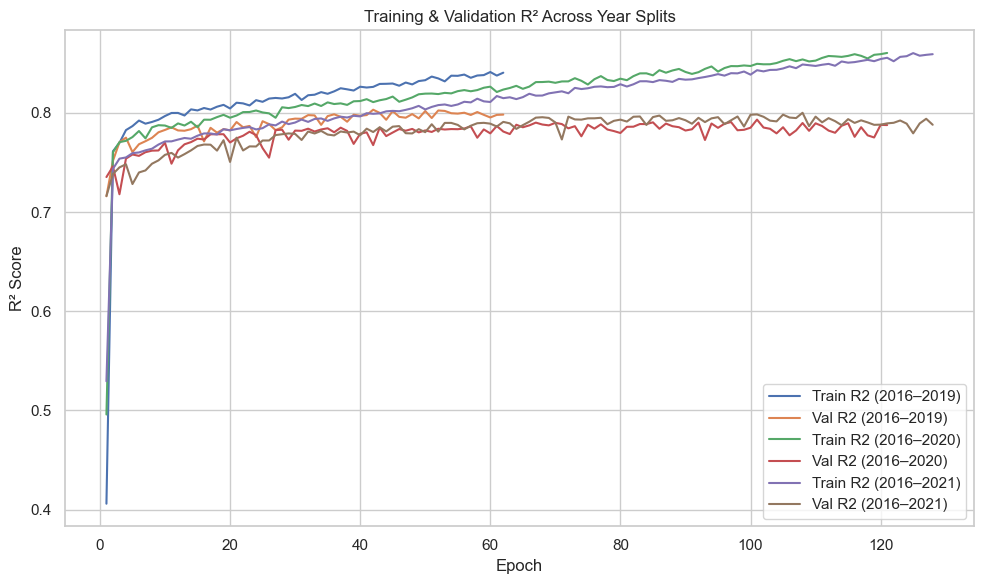

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# 2016–2019
plt.plot(range(1, len(Train_R2_per_epoch_2016_2019)+1),
         Train_R2_per_epoch_2016_2019,
         label="Train R2 (2016–2019)")

plt.plot(range(1, len(Validation_R2_per_epoch_2016_2019)+1),
         Validation_R2_per_epoch_2016_2019,
         label="Val R2 (2016–2019)")


# 2016–2020
plt.plot(range(1, len(Train_R2_per_epoch_2016_2020)+1),
         Train_R2_per_epoch_2016_2020,
         label="Train R2 (2016–2020)")

plt.plot(range(1, len(Validation_R2_per_epoch_2016_2020)+1),
         Validation_R2_per_epoch_2016_2020,
         label="Val R2 (2016–2020)")


# 2016–2021
plt.plot(range(1, len(Train_R2_per_epoch_2016_2021)+1),
         Train_R2_per_epoch_2016_2021,
         label="Train R2 (2016–2021)")

plt.plot(range(1, len(Validation_R2_per_epoch_2016_2021)+1),
         Validation_R2_per_epoch_2016_2021,
         label="Val R2 (2016–2021)")


plt.xlabel("Epoch")
plt.ylabel("R² Score")
plt.title("Training & Validation R² Across Year Splits")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

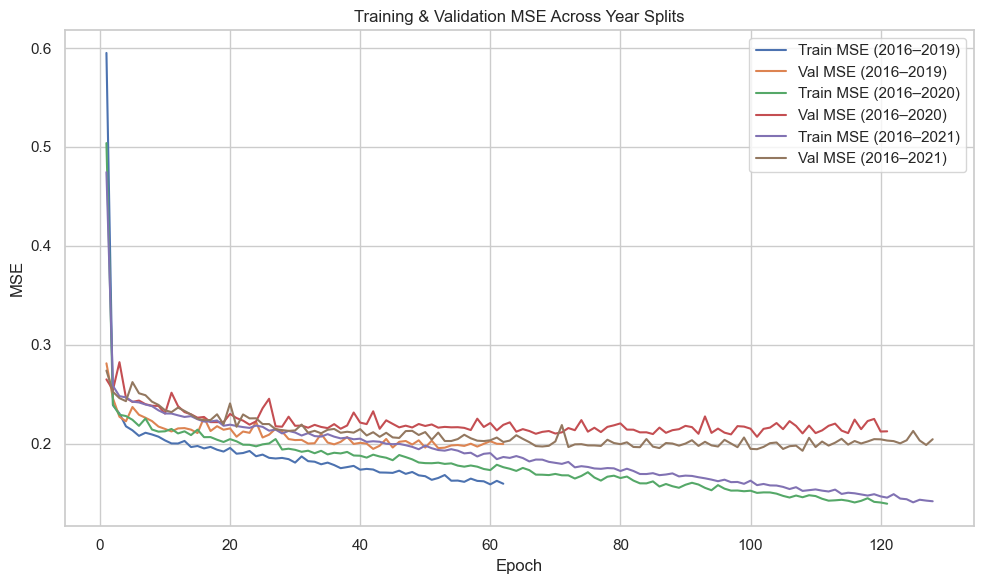

In [22]:
plt.figure(figsize=(10,6))

# 2016–2019
plt.plot(range(1, len(Train_MSE_per_epoch_2016_2019)+1),
         Train_MSE_per_epoch_2016_2019,
         label="Train MSE (2016–2019)")

plt.plot(range(1, len(Validation_MSE_per_epoch_2016_2019)+1),
         Validation_MSE_per_epoch_2016_2019,
         label="Val MSE (2016–2019)")


# 2016–2020
plt.plot(range(1, len(Train_MSE_per_epoch_2016_2020)+1),
         Train_MSE_per_epoch_2016_2020,
         label="Train MSE (2016–2020)")

plt.plot(range(1, len(Validation_MSE_per_epoch_2016_2020)+1),
         Validation_MSE_per_epoch_2016_2020,
         label="Val MSE (2016–2020)")


# 2016–2021
plt.plot(range(1, len(Train_MSE_per_epoch_2016_2021)+1),
         Train_MSE_per_epoch_2016_2021,
         label="Train MSE (2016–2021)")

plt.plot(range(1, len(Validation_MSE_per_epoch_2016_2021)+1),
         Validation_MSE_per_epoch_2016_2021,
         label="Val MSE (2016–2021)")


plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training & Validation MSE Across Year Splits")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = len(feature_cols)  # number of features after preprocessing
model = CornYieldTransformer(
    n_features=input_dim,
    emb_dim=128,      # same as used during training
    num_heads=8,      # same as used during training
    num_blocks=2,     # same as used during training
    dropout=0.2
).to(device)

# ------------------------------
# Load the best saved weights
# ------------------------------
checkpoint_path = "best_cross_attention_model.pth"  # make sure to save training weights to this path
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()  # set to evaluation mode

# Make sure your test_df still has the original 'year' column for splitting
YEARS = [2021]

for year in YEARS:
    # Filter rows for the current year (original, unscaled year column)
    year_df = test_df[test_df["year"] == year].reset_index(drop=True)
    
    if len(year_df) == 0:
        print(f"No data for year {year}")
        continue

    # Use the flattened dataset class (feature_cols includes HIST_AVG_YIELD)
    year_dataset = FlattenedCornDataset(year_df)
    year_loader  = DataLoader(year_dataset, batch_size=32, shuffle=False)

    all_preds_scaled, all_truths_scaled = [], []

    with torch.no_grad():
        for X, y in year_loader:
            # Move to device
            X, y = X.to(device), y.to(device)
            # Forward pass
            preds = model(X)  # model expects a single input vector now
            # Collect results
            all_preds_scaled.append(preds.cpu().numpy())
            all_truths_scaled.append(y.cpu().numpy())

    all_preds_scaled  = np.vstack(all_preds_scaled)
    all_truths_scaled = np.vstack(all_truths_scaled)

    # Convert scaled predictions back to real yield
    all_preds_real  = scaler_y.inverse_transform(all_preds_scaled)
    all_truths_real = scaler_y.inverse_transform(all_truths_scaled)

    # Compute metrics
    mse_scaled = mean_squared_error(all_truths_scaled, all_preds_scaled)
    r2_scaled  = r2_score(all_truths_scaled, all_preds_scaled)
    mse_real   = mean_squared_error(all_truths_real, all_preds_real)
    r2_real    = r2_score(all_truths_real, all_preds_real)

    print(f"--- Year {year} ---")
    print(f"MSE (scaled): {mse_scaled:.4f}, R2 (scaled): {r2_scaled:.4f}")
    print(f"MSE (real):   {mse_real:.4f}, R2 (real):   {r2_real:.4f}")


--- Year 2021 ---
MSE (scaled): 0.4556, R2 (scaled): 0.5851
MSE (real):   567.2990, R2 (real):   0.5851


### Model comparison using R2 & MSE

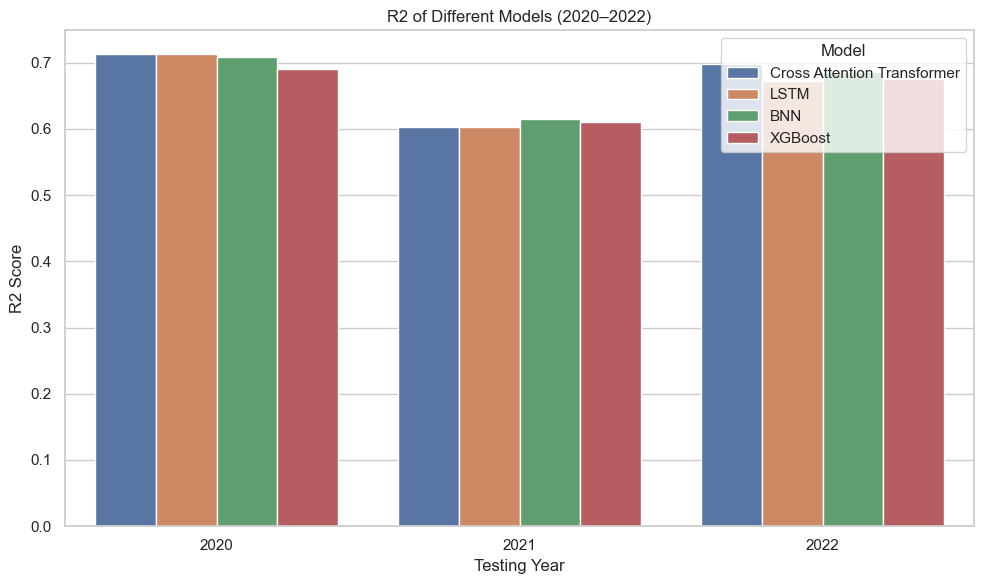

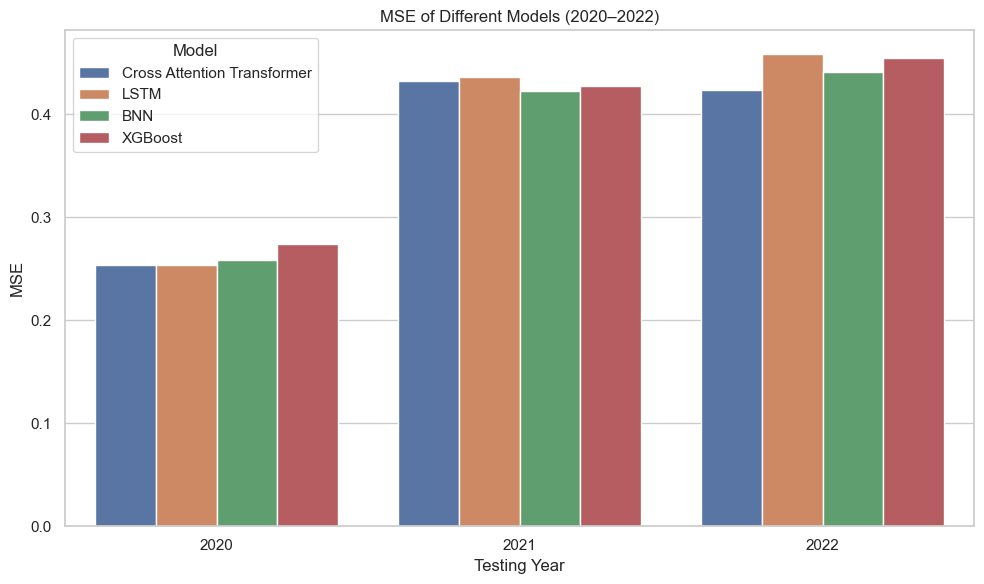

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create Data
data = {
    "Model": [
        "Cross Attention Transformer",
        "LSTM",
        "BNN",
        "XGBoost"
    ],
    "2020_MSE": [0.254, 0.2538, 0.2582, 0.2742],
    "2020_R2": [0.7131, 0.713, 0.7081, 0.69],
    "2021_MSE": [0.4321, 0.4366, 0.4227, 0.4276],
    "2021_R2": [0.6031, 0.6024, 0.615, 0.6105],
    "2022_MSE": [0.424, 0.4585, 0.4409, 0.4545],
    "2022_R2": [0.6974, 0.6727, 0.6853, 0.6756],
}

df = pd.DataFrame(data)

# Reshape for easier plotting
r2_df = df.melt(id_vars="Model",
                value_vars=["2020_R2", "2021_R2", "2022_R2"],
                var_name="Year",
                value_name="R2")

r2_df["Year"] = r2_df["Year"].str.replace("_R2", "")

mse_df = df.melt(id_vars="Model",
                 value_vars=["2020_MSE", "2021_MSE", "2022_MSE"],
                 var_name="Year",
                 value_name="MSE")

mse_df["Year"] = mse_df["Year"].str.replace("_MSE", "")

sns.set(style="whitegrid")

# -----------------------------
# Graph 1: R2 Comparison
# -----------------------------
plt.figure(figsize=(10, 6))
sns.barplot(data=r2_df, x="Year", y="R2", hue="Model")
plt.title("R2 of Different Models (2020–2022)")
plt.ylabel("R2 Score")
plt.xlabel("Testing Year")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# -----------------------------
# Graph 2: MSE Comparison
# -----------------------------
plt.figure(figsize=(10, 6))
sns.barplot(data=mse_df, x="Year", y="MSE", hue="Model")
plt.title("MSE of Different Models (2020–2022)")
plt.ylabel("MSE")
plt.xlabel("Testing Year")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

### SHAP Analysis for feature importance

In [24]:
import shap
import numpy as np

model.eval()

def model_predict(x_numpy):
    x_tensor = torch.from_numpy(x_numpy.astype(np.float32)).to(device)
    with torch.no_grad():
        preds = model(x_tensor).cpu().numpy()
    return preds

d:\Lovindya IIT project\code\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
YEARS = [2020, 2021, 2022]

feature_importances_by_year = {}

for year in YEARS:
    year_df = test_df[test_df["year"] == year].reset_index(drop=True)

    if len(year_df) == 0:
        print(f"No data for year {year}")
        continue

    print(f"\nRunning SHAP for year {year}...")

    # Extract numpy features (same order as feature_cols)
    X_year = year_df[feature_cols].values.astype(np.float32)

    # Use small background sample for speed
    background = shap.sample(X_year, 100, random_state=42)

    explainer = shap.KernelExplainer(model_predict, background)

    shap_values = explainer.shap_values(X_year, nsamples=200)

    shap_values = np.array(shap_values)

    # If SHAP returned 3D array, squeeze last dimension
    shap_values = np.array(shap_values)

    if shap_values.ndim == 3:
        shap_values = shap_values.squeeze()

    feature_importance = np.mean(np.abs(shap_values), axis=0)
    feature_importance = feature_importance.astype(float)

    # Print feature importance
    print(f"\nFeature Importance for {year}:")
    for feat, val in zip(feature_cols, feature_importance):
        print(f"{feat}: {val:.6f}")


Running SHAP for year 2020...


100%|██████████| 1234/1234 [01:37<00:00, 12.62it/s]



Feature Importance for 2020:
ppt (mm)_AVG: 0.073578
tmax (degrees C)_AVG: 0.094380
tmean (degrees C)_AVG: 0.027101
tmin (degrees C)_AVG: 0.098642
ssm_AVG: 0.046618
susm_AVG: 0.021075
EVI_AVG: 0.043420
GCI_AVG: 0.073363
NDWI_AVG: 0.034718
NDVI_AVG: 0.167234
AWC: 0.085804
SOM: 0.018509
CEC: 0.063378
state_idx: 0.045596
HIST_AVG_YIELD: 0.515287

Running SHAP for year 2021...


100%|██████████| 1093/1093 [01:26<00:00, 12.66it/s]



Feature Importance for 2021:
ppt (mm)_AVG: 0.088516
tmax (degrees C)_AVG: 0.071200
tmean (degrees C)_AVG: 0.031329
tmin (degrees C)_AVG: 0.117612
ssm_AVG: 0.076529
susm_AVG: 0.018812
EVI_AVG: 0.040599
GCI_AVG: 0.089099
NDWI_AVG: 0.043915
NDVI_AVG: 0.197560
AWC: 0.090866
SOM: 0.019930
CEC: 0.065106
state_idx: 0.035025
HIST_AVG_YIELD: 0.502283

Running SHAP for year 2022...


100%|██████████| 1148/1148 [01:30<00:00, 12.66it/s]


Feature Importance for 2022:
ppt (mm)_AVG: 0.076221
tmax (degrees C)_AVG: 0.116207
tmean (degrees C)_AVG: 0.030930
tmin (degrees C)_AVG: 0.086072
ssm_AVG: 0.032046
susm_AVG: 0.013172
EVI_AVG: 0.046422
GCI_AVG: 0.080086
NDWI_AVG: 0.045503
NDVI_AVG: 0.160207
AWC: 0.074845
SOM: 0.019222
CEC: 0.047317
state_idx: 0.037611
HIST_AVG_YIELD: 0.518381


In [32]:
shap_data={
2020:{"ppt (mm)_AVG": 0.073578,
"tmax (degrees C)_AVG": 0.094380,
"tmean (degrees C)_AVG": 0.027101,
"tmin (degrees C)_AVG": 0.098642,
"ssm_AVG": 0.046618,
"susm_AVG": 0.021075,
"EVI_AVG": 0.043420,
"GCI_AVG": 0.073363,
"NDWI_AVG": 0.034718,
"NDVI_AVG": 0.167234,
"AWC": 0.085804,
"SOM": 0.018509,
"CEC": 0.063378,
"state_idx": 0.045596,
"HIST_AVG_YIELD": 0.515287,},

2021: {"ppt (mm)_AVG": 0.088516,
"tmax (degrees C)_AVG": 0.071200,
"tmean (degrees C)_AVG": 0.031329,
"tmin (degrees C)_AVG": 0.117612,
"ssm_AVG": 0.076529,
"susm_AVG": 0.018812,   
"EVI_AVG": 0.040599,
"GCI_AVG": 0.089099,
"NDWI_AVG": 0.043915,
"NDVI_AVG": 0.197560,
"AWC": 0.090866,
"SOM": 0.019930,
"CEC": 0.065106,
"state_idx": 0.035025,
"HIST_AVG_YIELD": 0.502283},

2022: {"ppt (mm)_AVG": 0.076221,
"tmax (degrees C)_AVG": 0.116207,
"tmean (degrees C)_AVG": 0.030930,
"tmin (degrees C)_AVG": 0.086072,
"ssm_AVG": 0.032046,
"susm_AVG": 0.013172,
"EVI_AVG": 0.046422,
"GCI_AVG": 0.080086,
"NDWI_AVG": 0.045503,
"NDVI_AVG": 0.160207,
"AWC": 0.074845,
"SOM": 0.019222,
"CEC": 0.047317,
"state_idx": 0.037611,
"HIST_AVG_YIELD": 0.518381}
}

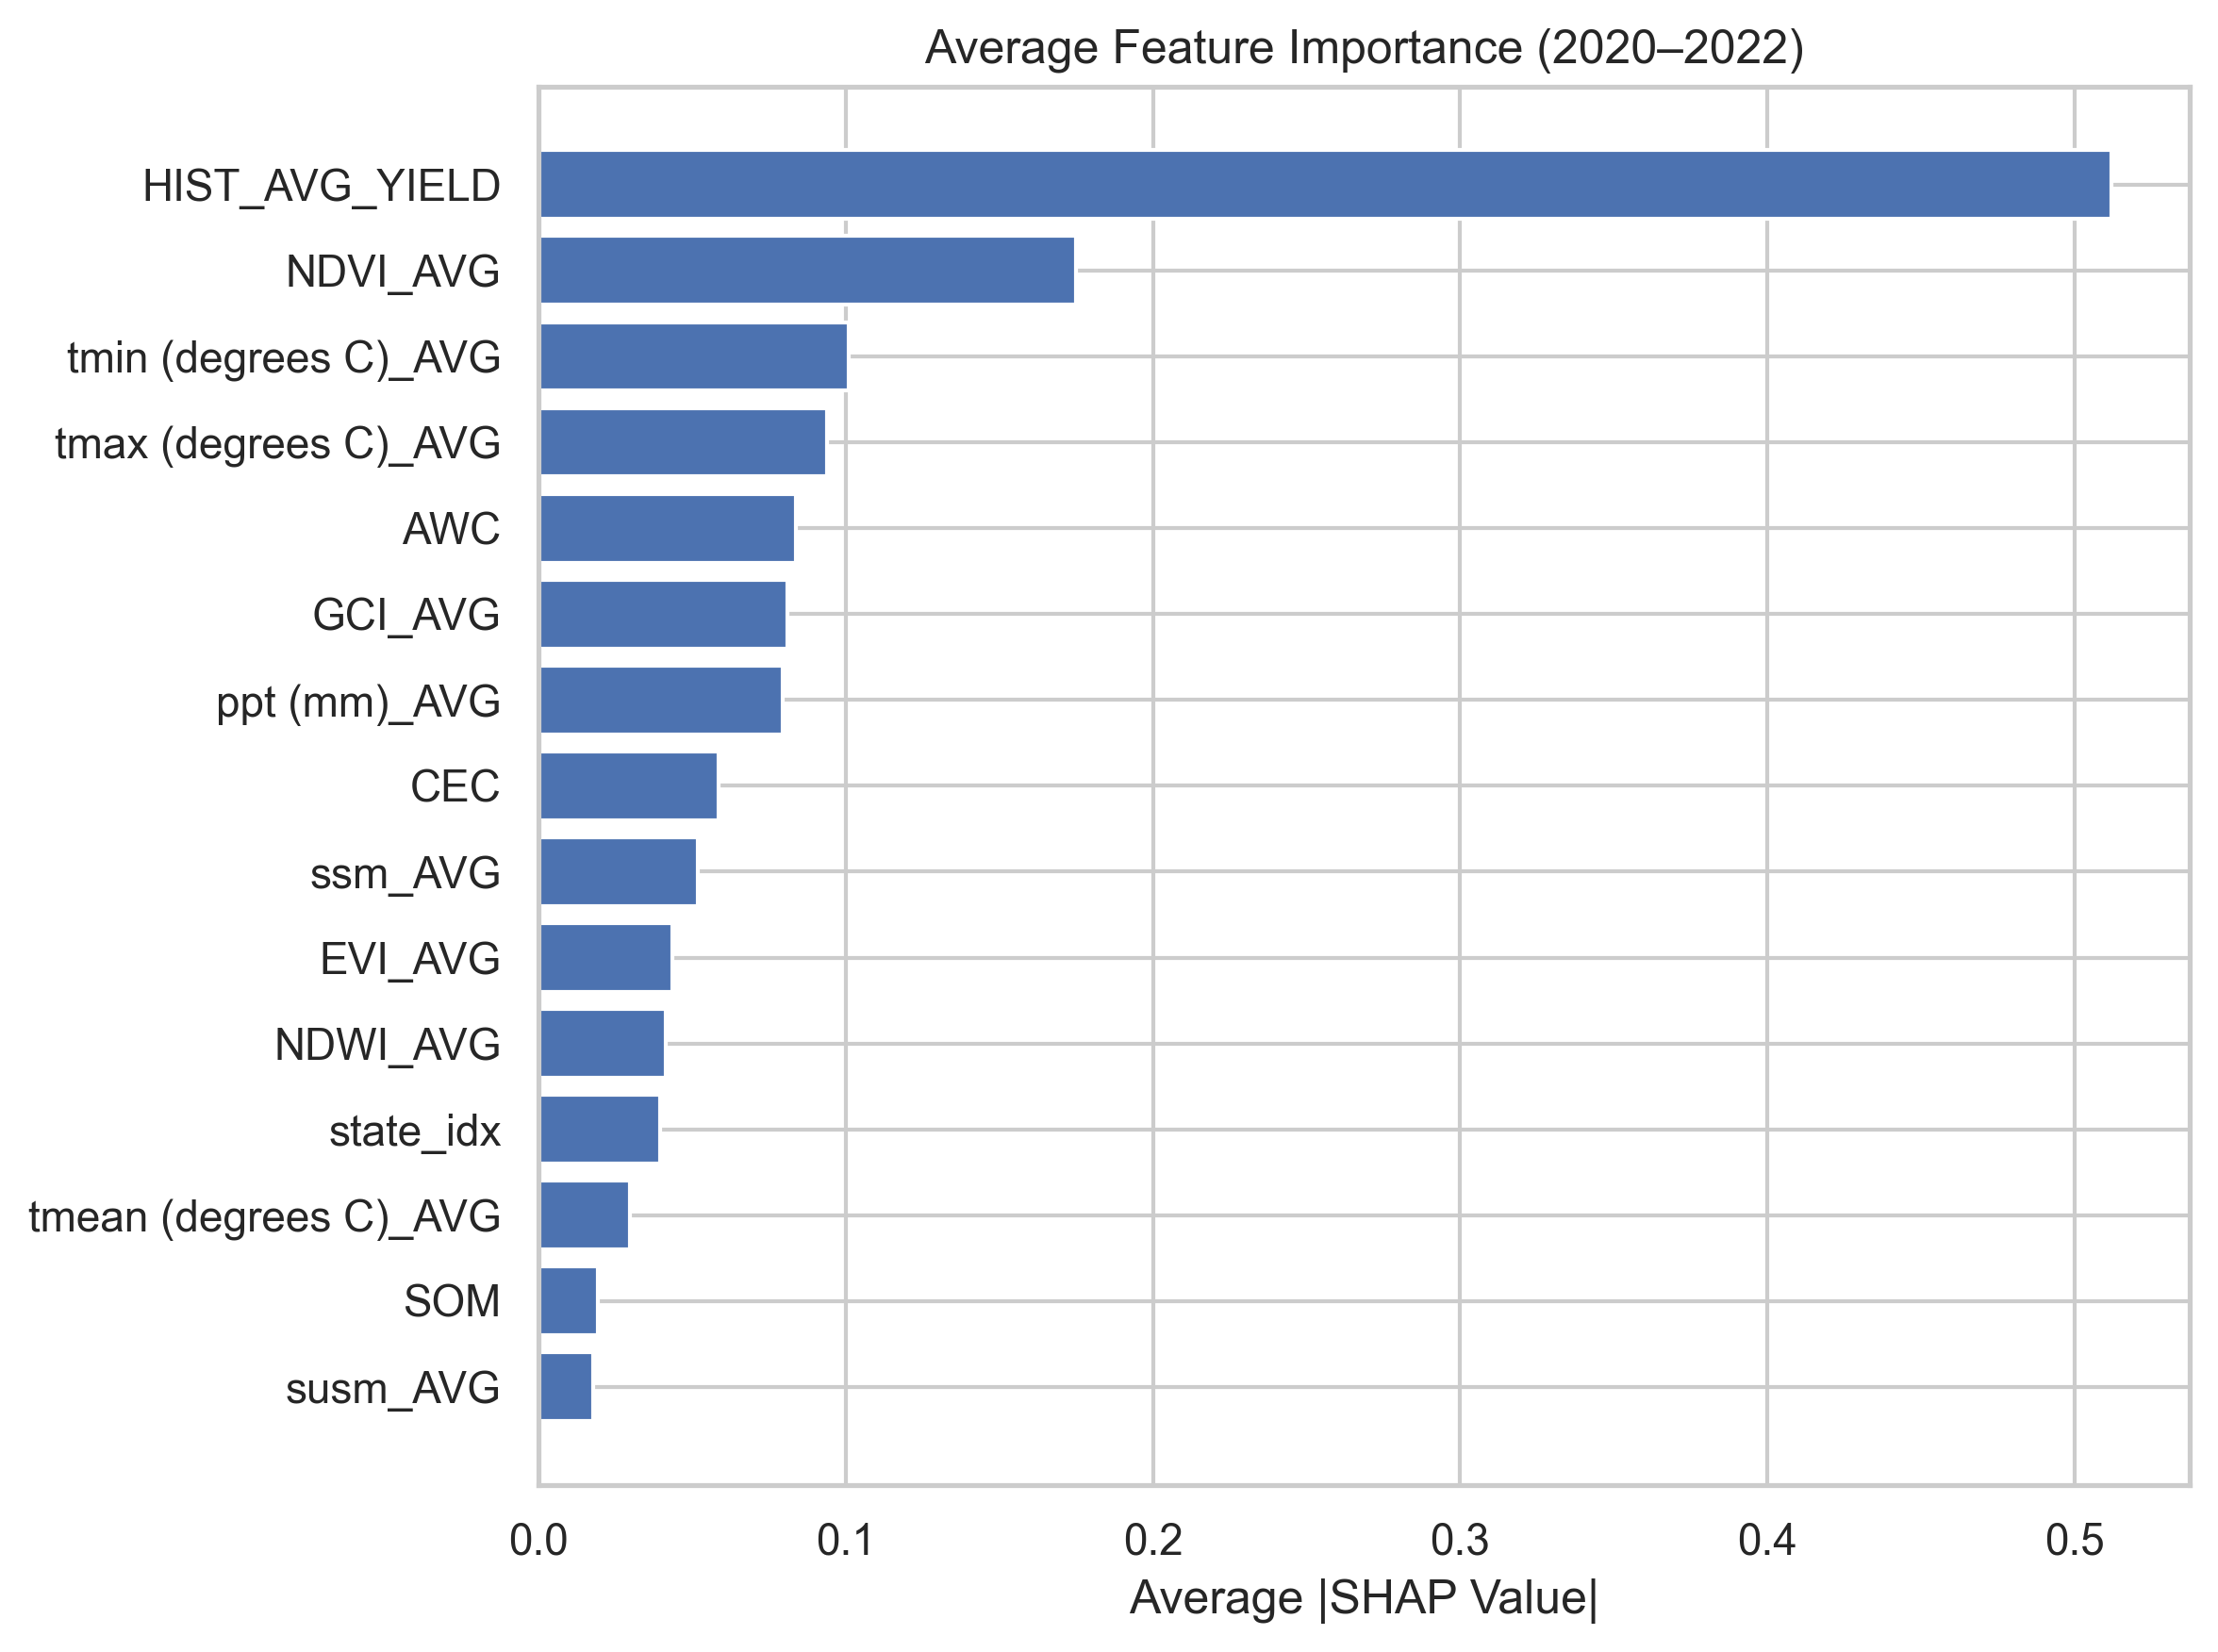

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Get feature names
feature_cols = list(shap_data[2020].keys())

# 2️⃣ Stack values per year
all_values = np.array([
    [shap_data[year][feat] for feat in feature_cols]
    for year in sorted(shap_data.keys())
])  # shape: (3, n_features)

# 3️⃣ Compute average over years (axis=0)
avg_importance = np.mean(all_values, axis=0)

# 4️⃣ Sort features by average importance
sorted_idx = np.argsort(avg_importance)[::-1]
sorted_features = np.array(feature_cols)[sorted_idx]
sorted_values = avg_importance[sorted_idx]

# 5️⃣ Plot
plt.figure(figsize=(8,6), dpi=300)
plt.barh(sorted_features, sorted_values)
plt.gca().invert_yaxis()  # largest on top
plt.xlabel("Average |SHAP Value|")
plt.title("Average Feature Importance (2020–2022)")
plt.tight_layout()
plt.show()